In [1]:
import numpy as np
import pandas as pd
import dill as pickle
import matplotlib.pyplot as plt
import plotly.express as px
from typing import List, Dict
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from data_process import DataProcessor
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import differential_evolution
import json
import os
import math
from pathlib import Path
import time
from IPython.display import clear_output
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
import shap

from colors_manager import ColorManager
from all_trajectories_figure import AllTrajectoriesFigure  
from particle_trajectory_fitting import ParticleTrajectoryFitting
from feature_collection import FeatureCollection
from clusterer import Clusterer

/opt/anaconda3/envs/Active_Matter/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Choice type of robots form

In [9]:
robots_form = 'oval' #'oval' or 'circle'
if robots_form == 'oval':
    with open('oval/data/oval_data_[30_bots_PWM_1_exp_1].pickle', 'rb') as file: 
        raw_data = pickle.load(file)
elif robots_form == 'circle':
    with open('circle/data/circle_data_00_330_[30_bots_PWM_10_15cw_15ccw_D_41cm].MP4.pickle', 'rb') as file: 
        raw_data = pickle.load(file)

# Cylindrically


In [3]:
processor = DataProcessor(raw_data)
coord_data, angle_data = processor.extract_data()
normalized_coord_data = processor.normalize_all_coordinates()
time_period=[0,200]
colors = ColorManager(coord_data=coord_data)

In [4]:
figure = AllTrajectoriesFigure(coord_data=coord_data, colors = colors, robots_form=robots_form,  time_period=time_period, save_flag=False)
figure.space_trajectories()
#figure.temporal_trajectories()
#figure.robots_moving()

In [5]:
fitting = ParticleTrajectoryFitting(coord_data=coord_data, maxiter=0, robots_form=robots_form,colors = colors, time_period=time_period, show_flag=False)
fitting.fit_particle_trajectories()

rmse_comp mean: 28.2092, rmse_particle mean: 27.0645
Columns: Index(['robot_id', 'omega_z_1', 'omega_z_2', 'omega_z_3', 'omega_z_4',
       'amp_z_1', 'amp_z_2', 'std_x', 'std_y', 'rmse_comp', 'rmse_particle',
       'particle_successfull', 'w', 'W', 'f', 'B', 'E0', 'Ex0', 'Ey0',
       'rmse_div', 'mean_v', 'mean_cuv', 'var_cuv'],
      dtype='object')


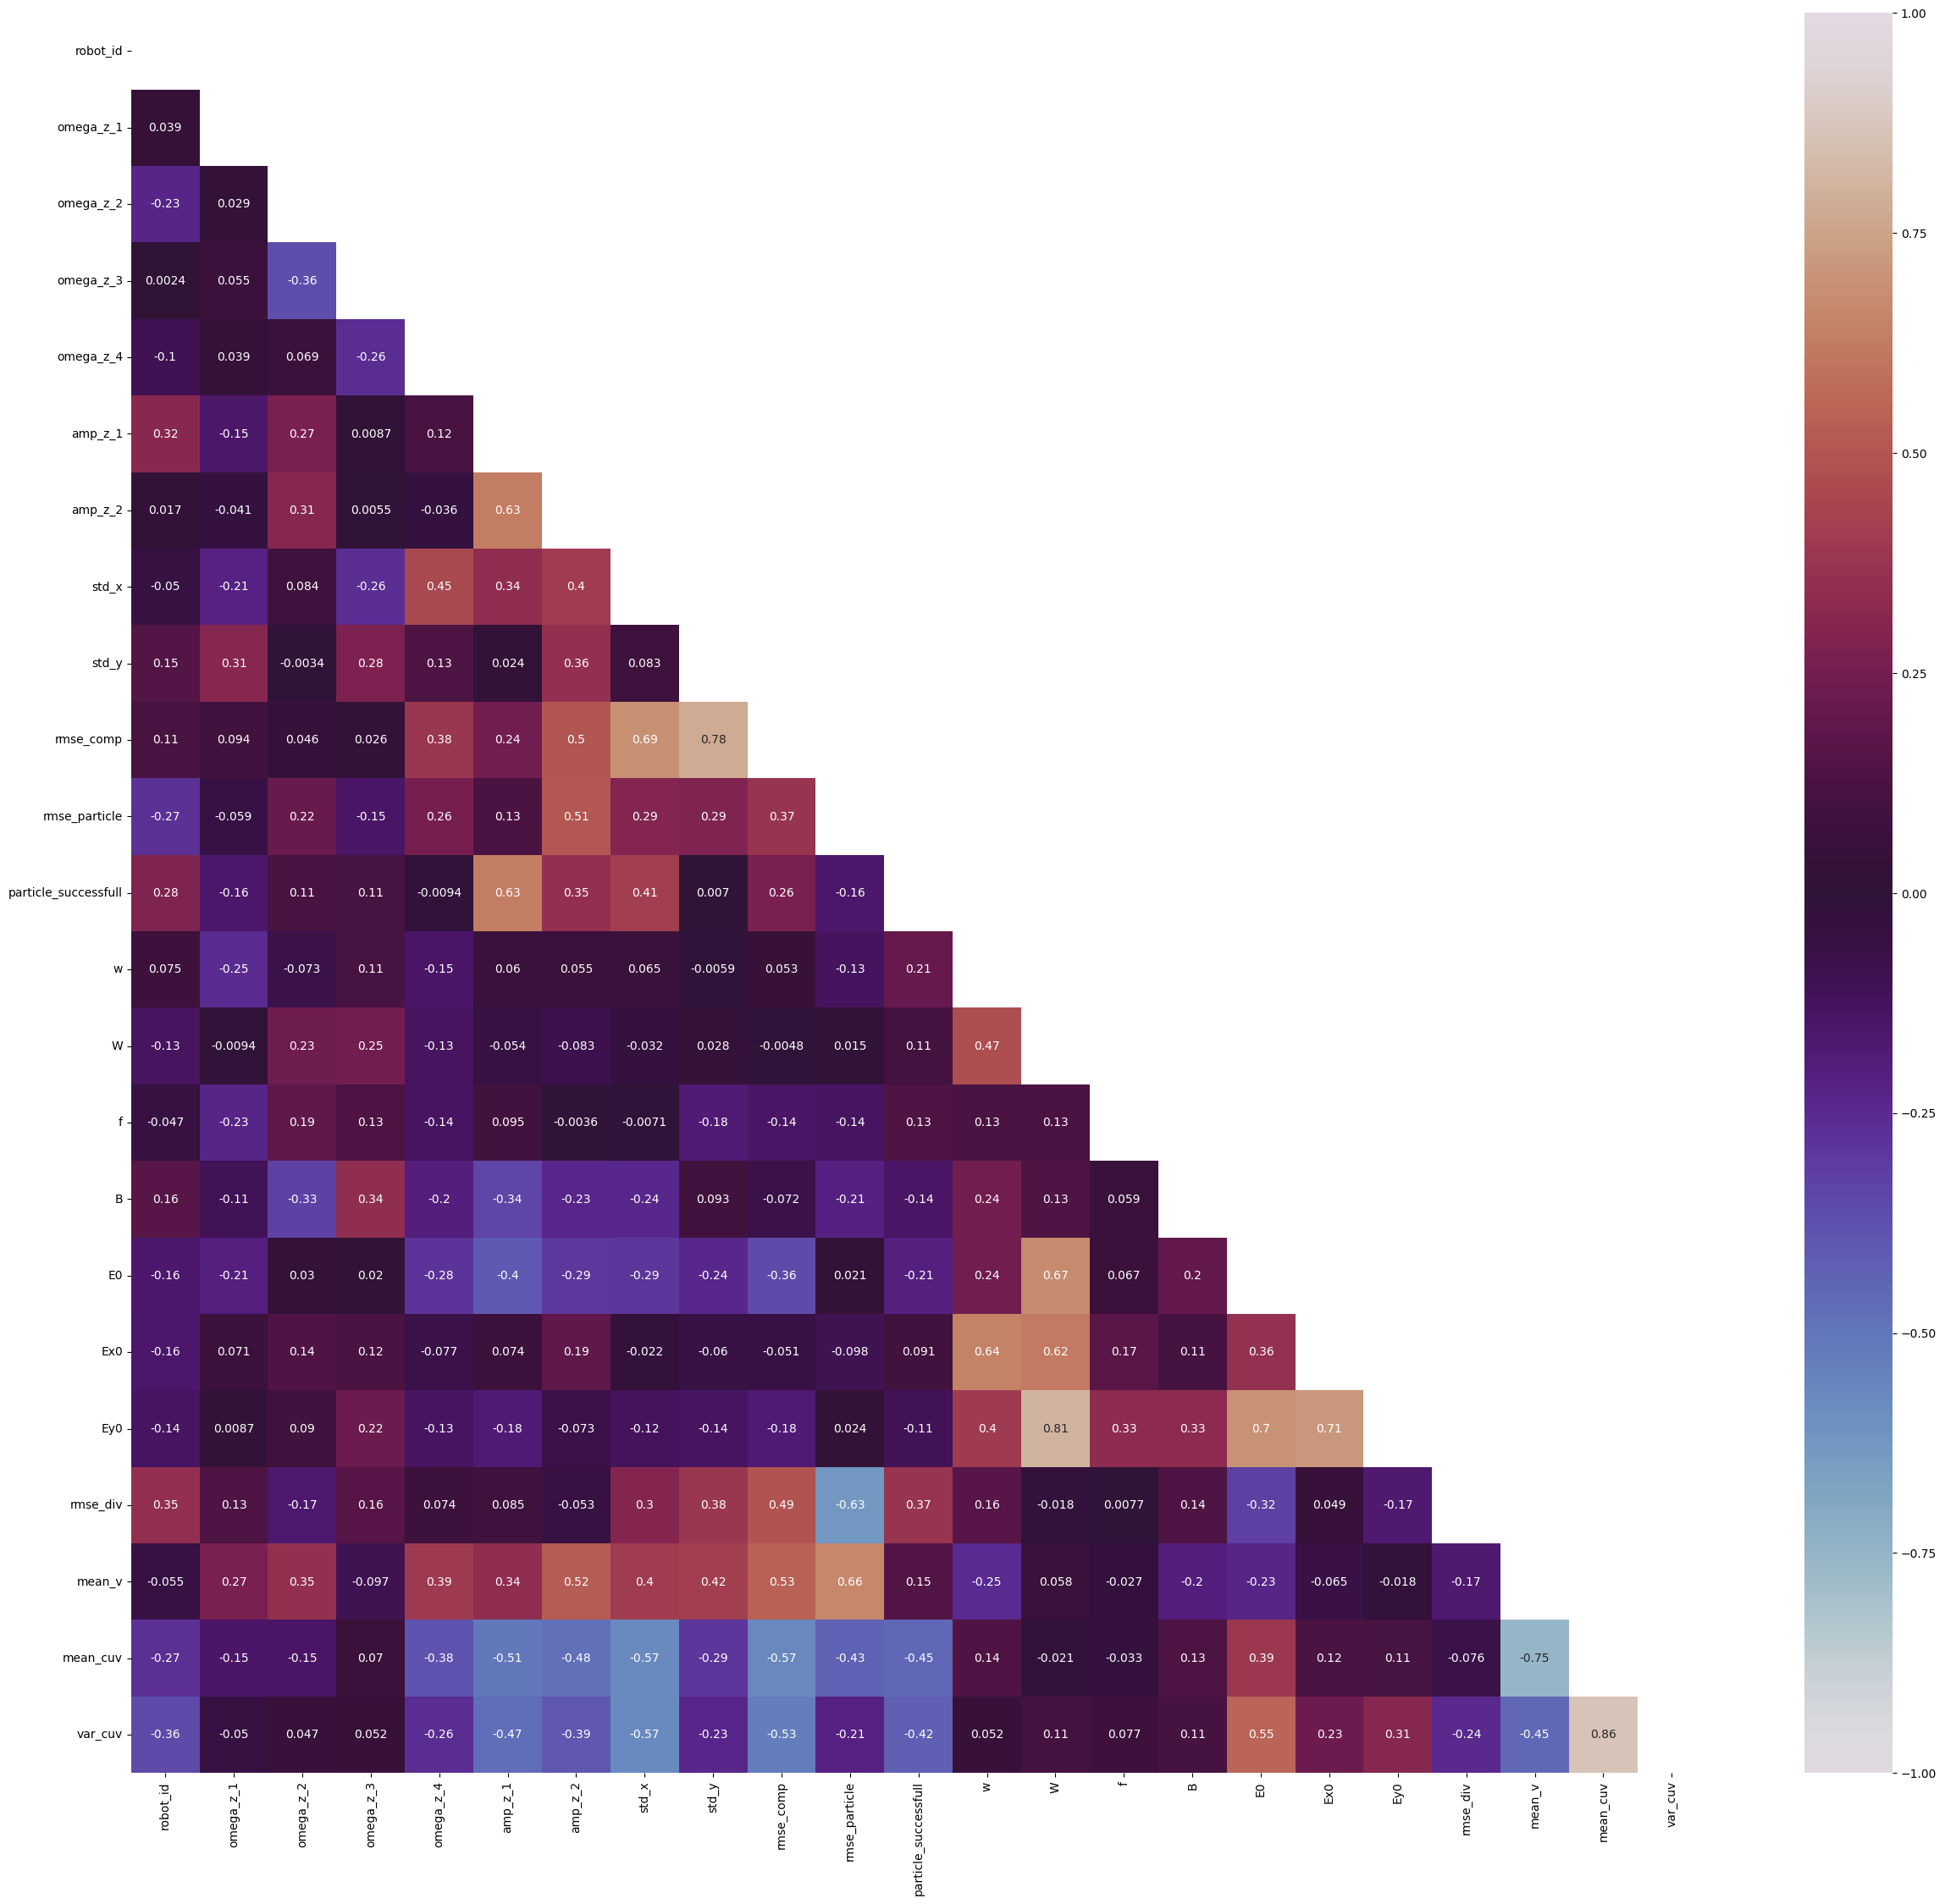

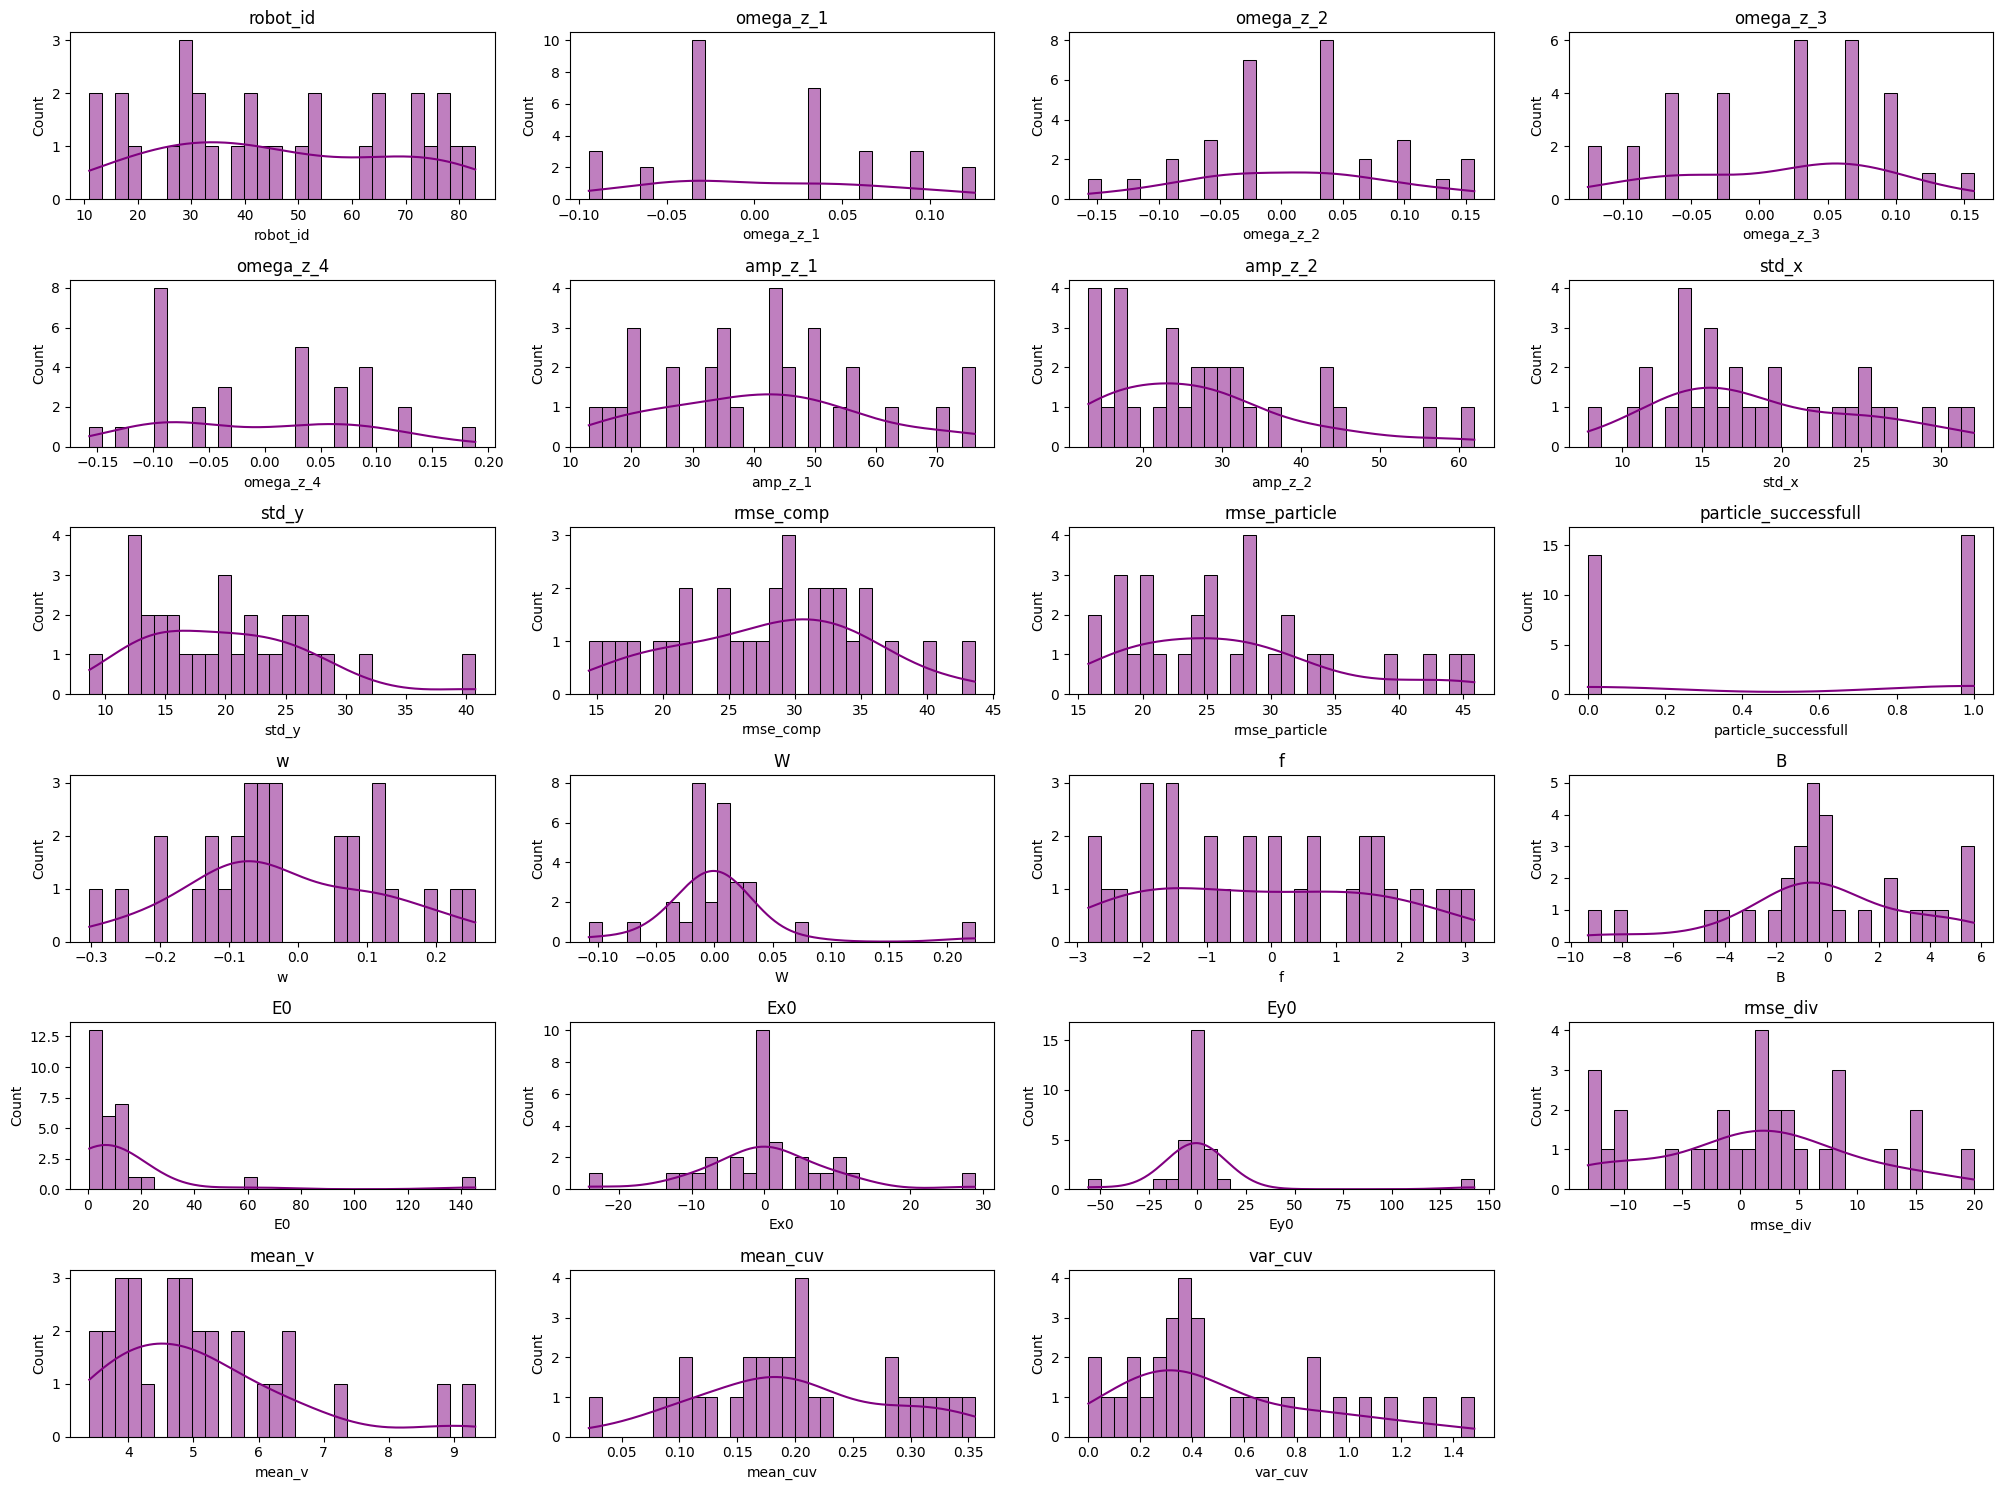

In [6]:
feature_creating = FeatureCollection(coord_data=coord_data, robots_form=robots_form, colors = colors, time_period=time_period, show_flag=False, save_flag = False)
feature_creating.feature_collection()
feature_creating.feature_analysis()

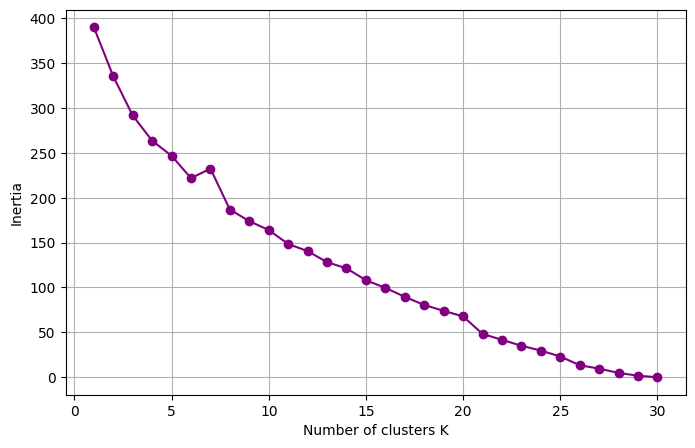

In [7]:
df = pd.read_csv(f'{robots_form}/robots_features.csv', index_col='robot_id')
df = df.drop(columns=['rmse_comp','rmse_particle','mean_v','mean_cuv','var_cuv','B','E0','Ex0','Ey0'])
X = df
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
inertia = []
K_range = range(1, 31) 

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, 'o-', color='purple')
plt.xlabel('Number of clusters K')
plt.ylabel('Inertia') # (Sum of squared distances)
plt.grid(True)
save_dir = Path(robots_form) / 'figures'
plt.savefig(save_dir/"elbow_plot.pdf", bbox_inches='tight')
plt.show()


          omega_z_1  omega_z_2  omega_z_3  omega_z_4    amp_z_1    amp_z_2  \
robot_id                                                                     
29        -0.062832   0.031416  -0.094248  -0.031416  21.095132  14.153143   
34         0.031416  -0.157080  -0.031416   0.062832  27.674387  25.195924   
65        -0.031416   0.094248  -0.125664   0.125664  50.077787  23.530953   
72        -0.031416  -0.125664   0.031416  -0.094248  21.059965  16.737161   
17        -0.031416   0.031416   0.094248  -0.094248  50.242053  34.163781   
30        -0.031416  -0.062832   0.157080   0.031416  33.255463  17.872490   
41         0.094248   0.031416   0.125664  -0.094248  43.224707  30.999339   
44        -0.031416   0.031416   0.094248  -0.157080  57.019650  55.905228   
54        -0.094248  -0.031416   0.031416   0.062832  45.587762  43.626924   
66        -0.031416   0.031416   0.094248  -0.062832  45.856488  30.556152   
79         0.031416  -0.094248   0.062832  -0.125664  44.048699 

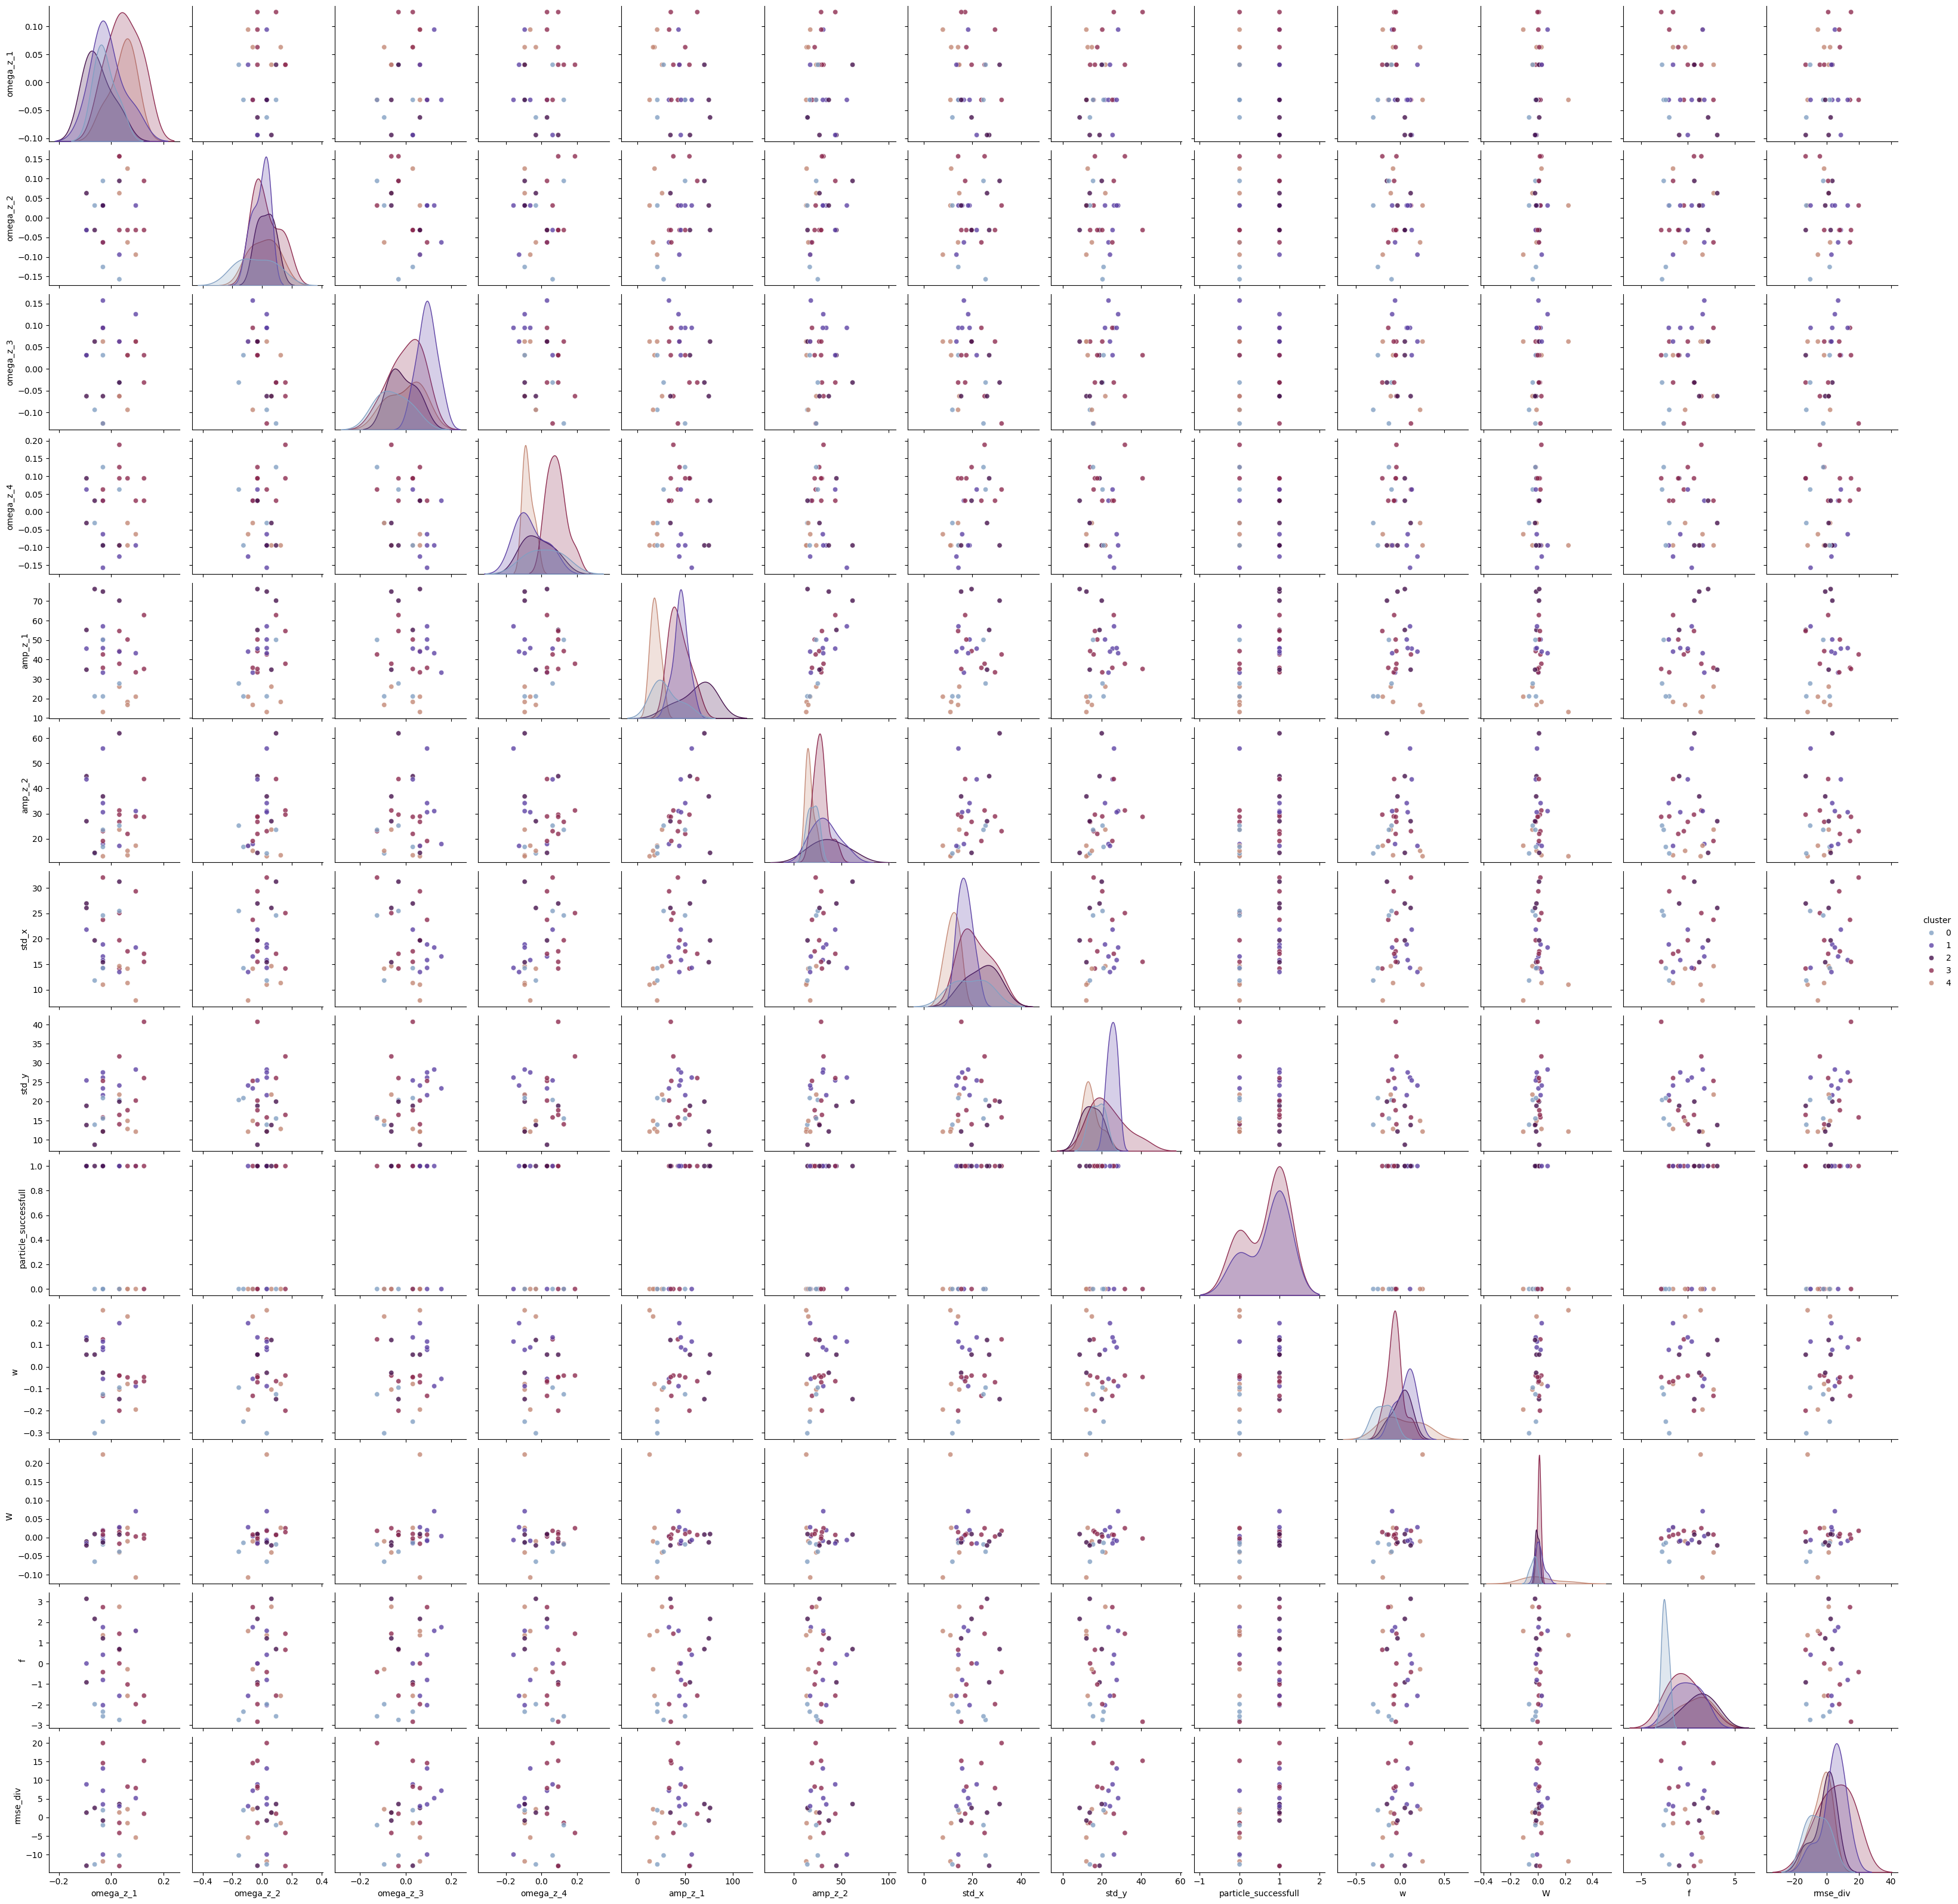

In [8]:
clusters = Clusterer(df,coord_data = coord_data,  robots_form=robots_form ,n_clusters = 5, colors = colors, time_period = time_period, save_flag = True)
clusters.cluster_creating()
clusters.cluster_analysis()

# Oval


In [10]:
processor = DataProcessor(raw_data)
coord_data, angle_data = processor.extract_data()
normalized_coord_data = processor.normalize_all_coordinates()
time_period=[0,200]
colors = ColorManager(coord_data=coord_data)

In [11]:
figure = AllTrajectoriesFigure(coord_data=coord_data, colors = colors, robots_form=robots_form,  time_period=time_period, save_flag=False)
figure.space_trajectories()
#figure.temporal_trajectories()
#figure.robots_moving()

rmse_comp mean: 41.6820
Columns: Index(['robot_id', 'omega_z_1', 'omega_z_2', 'omega_z_3', 'omega_z_4',
       'amp_z_1', 'amp_z_2', 'std_x', 'std_y', 'rmse_comp', 'mean_v',
       'mean_cuv', 'var_cuv'],
      dtype='object')


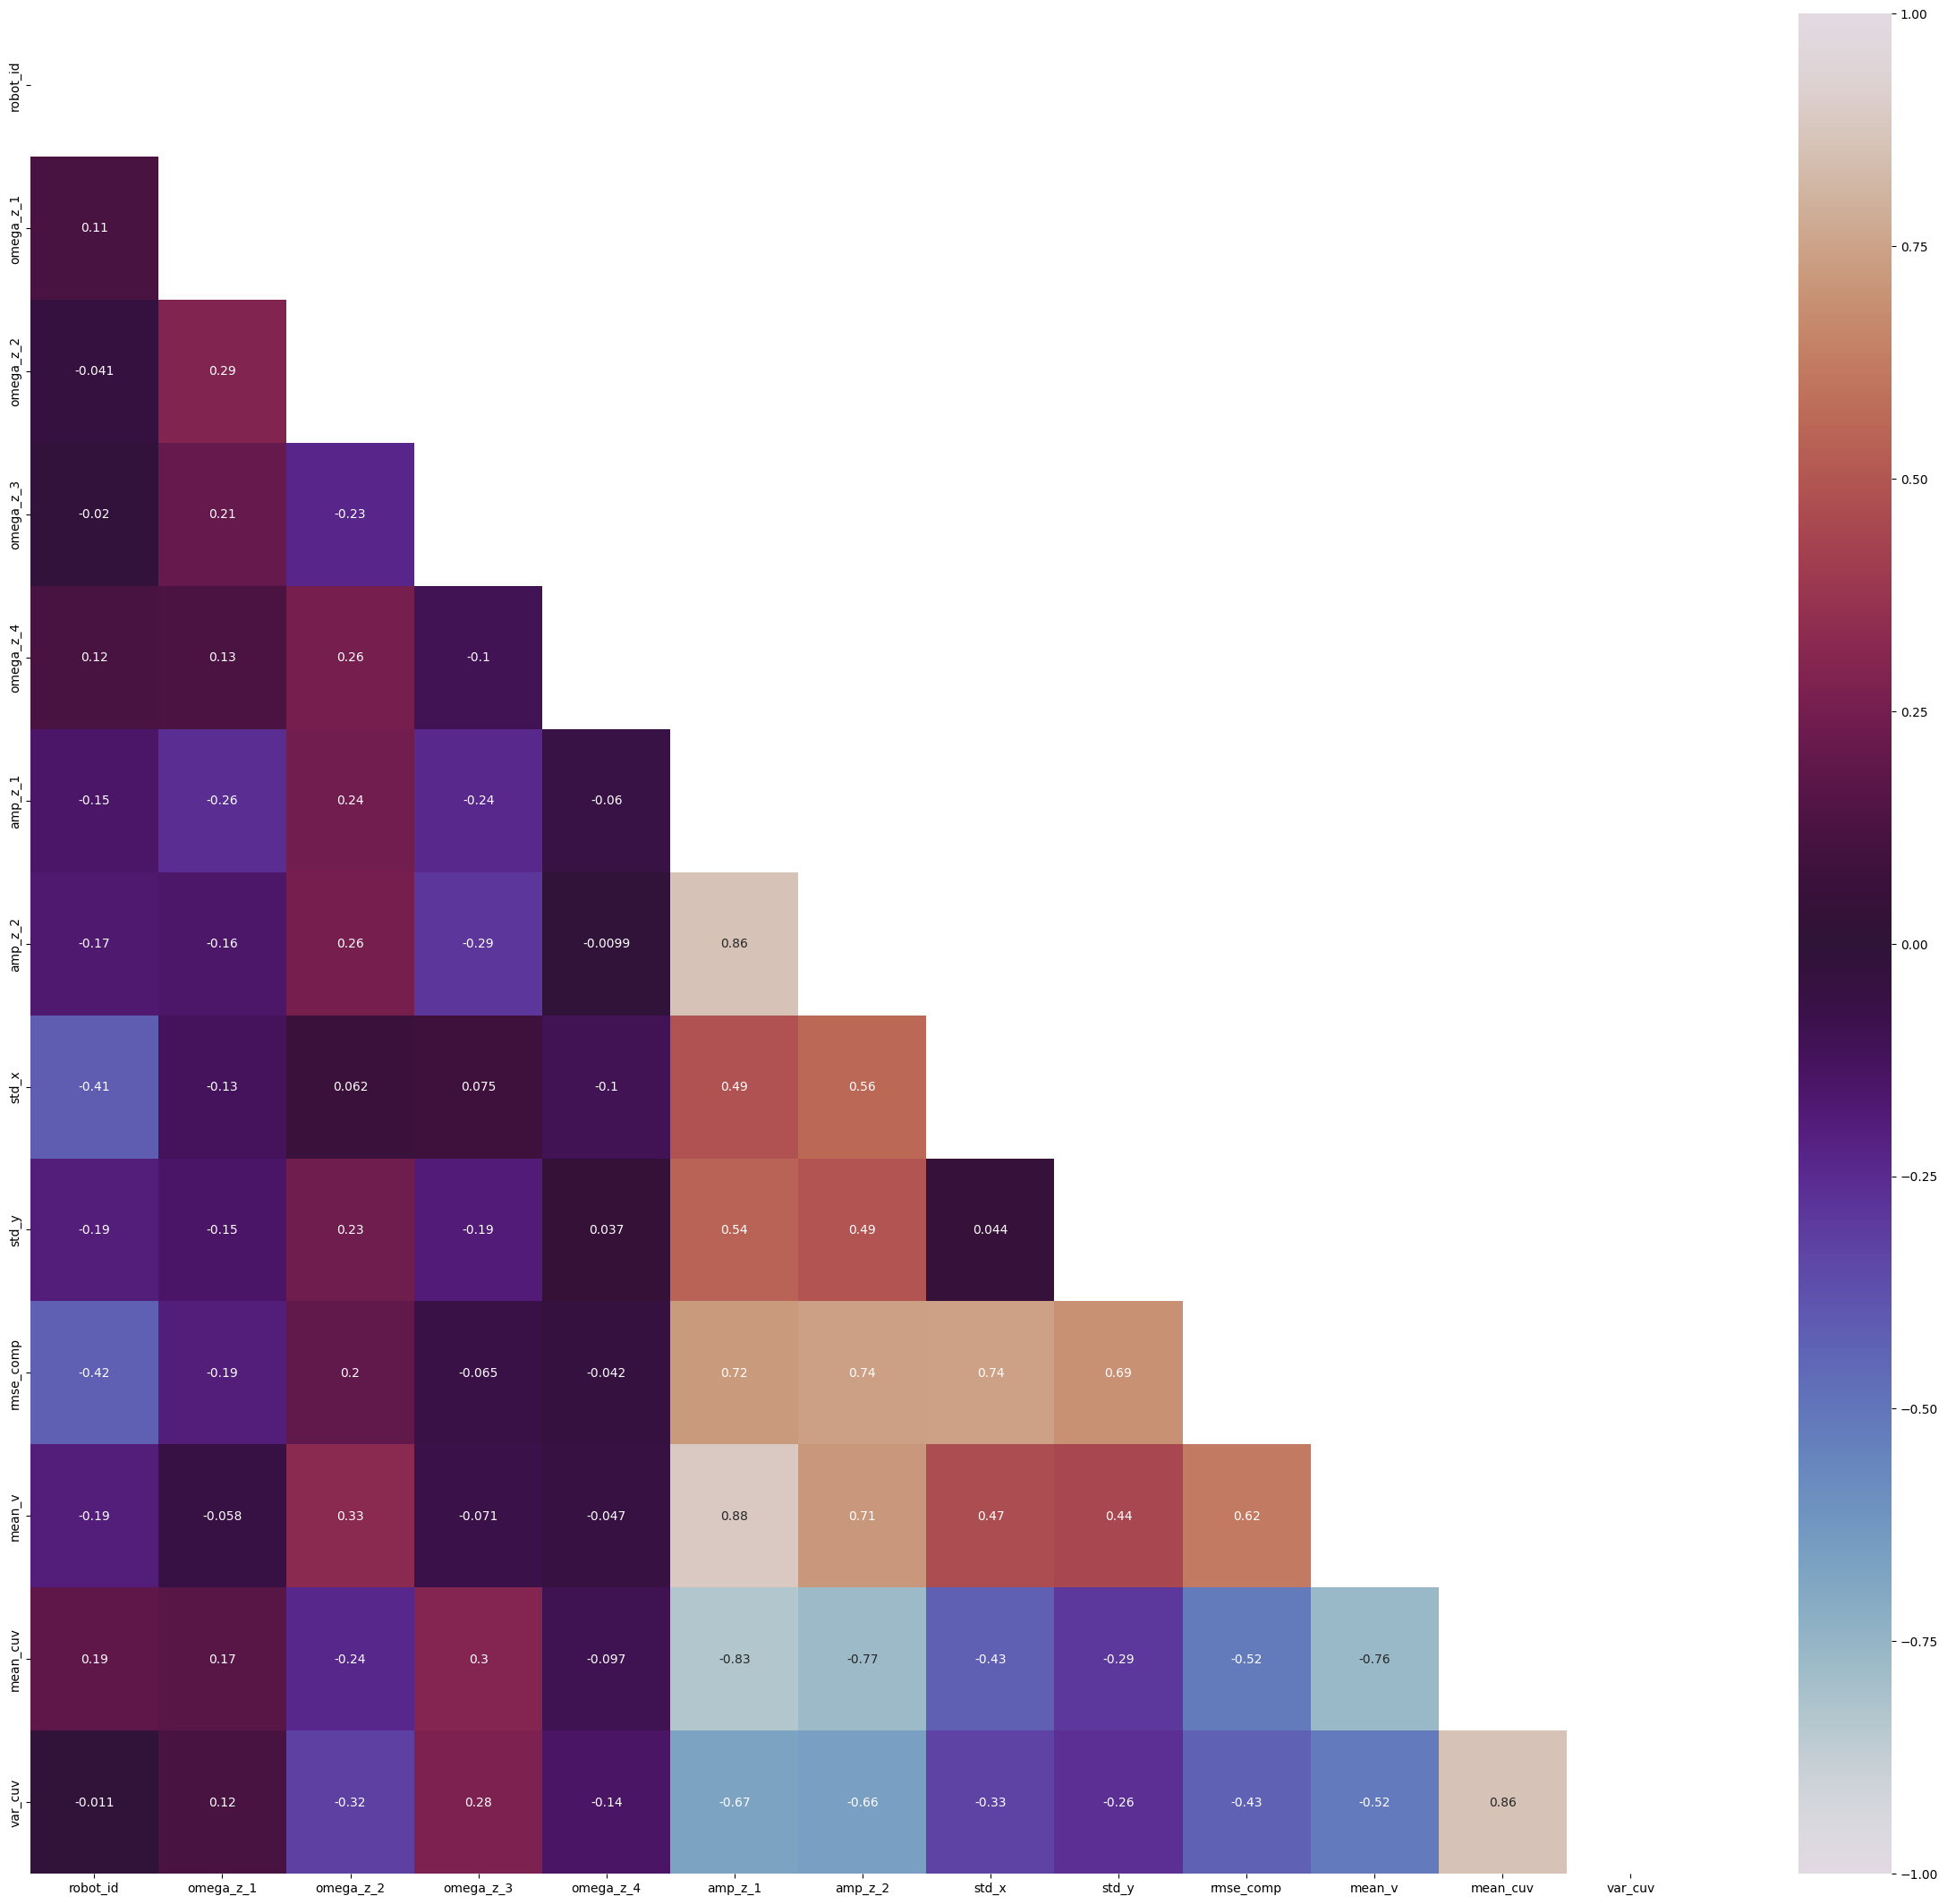

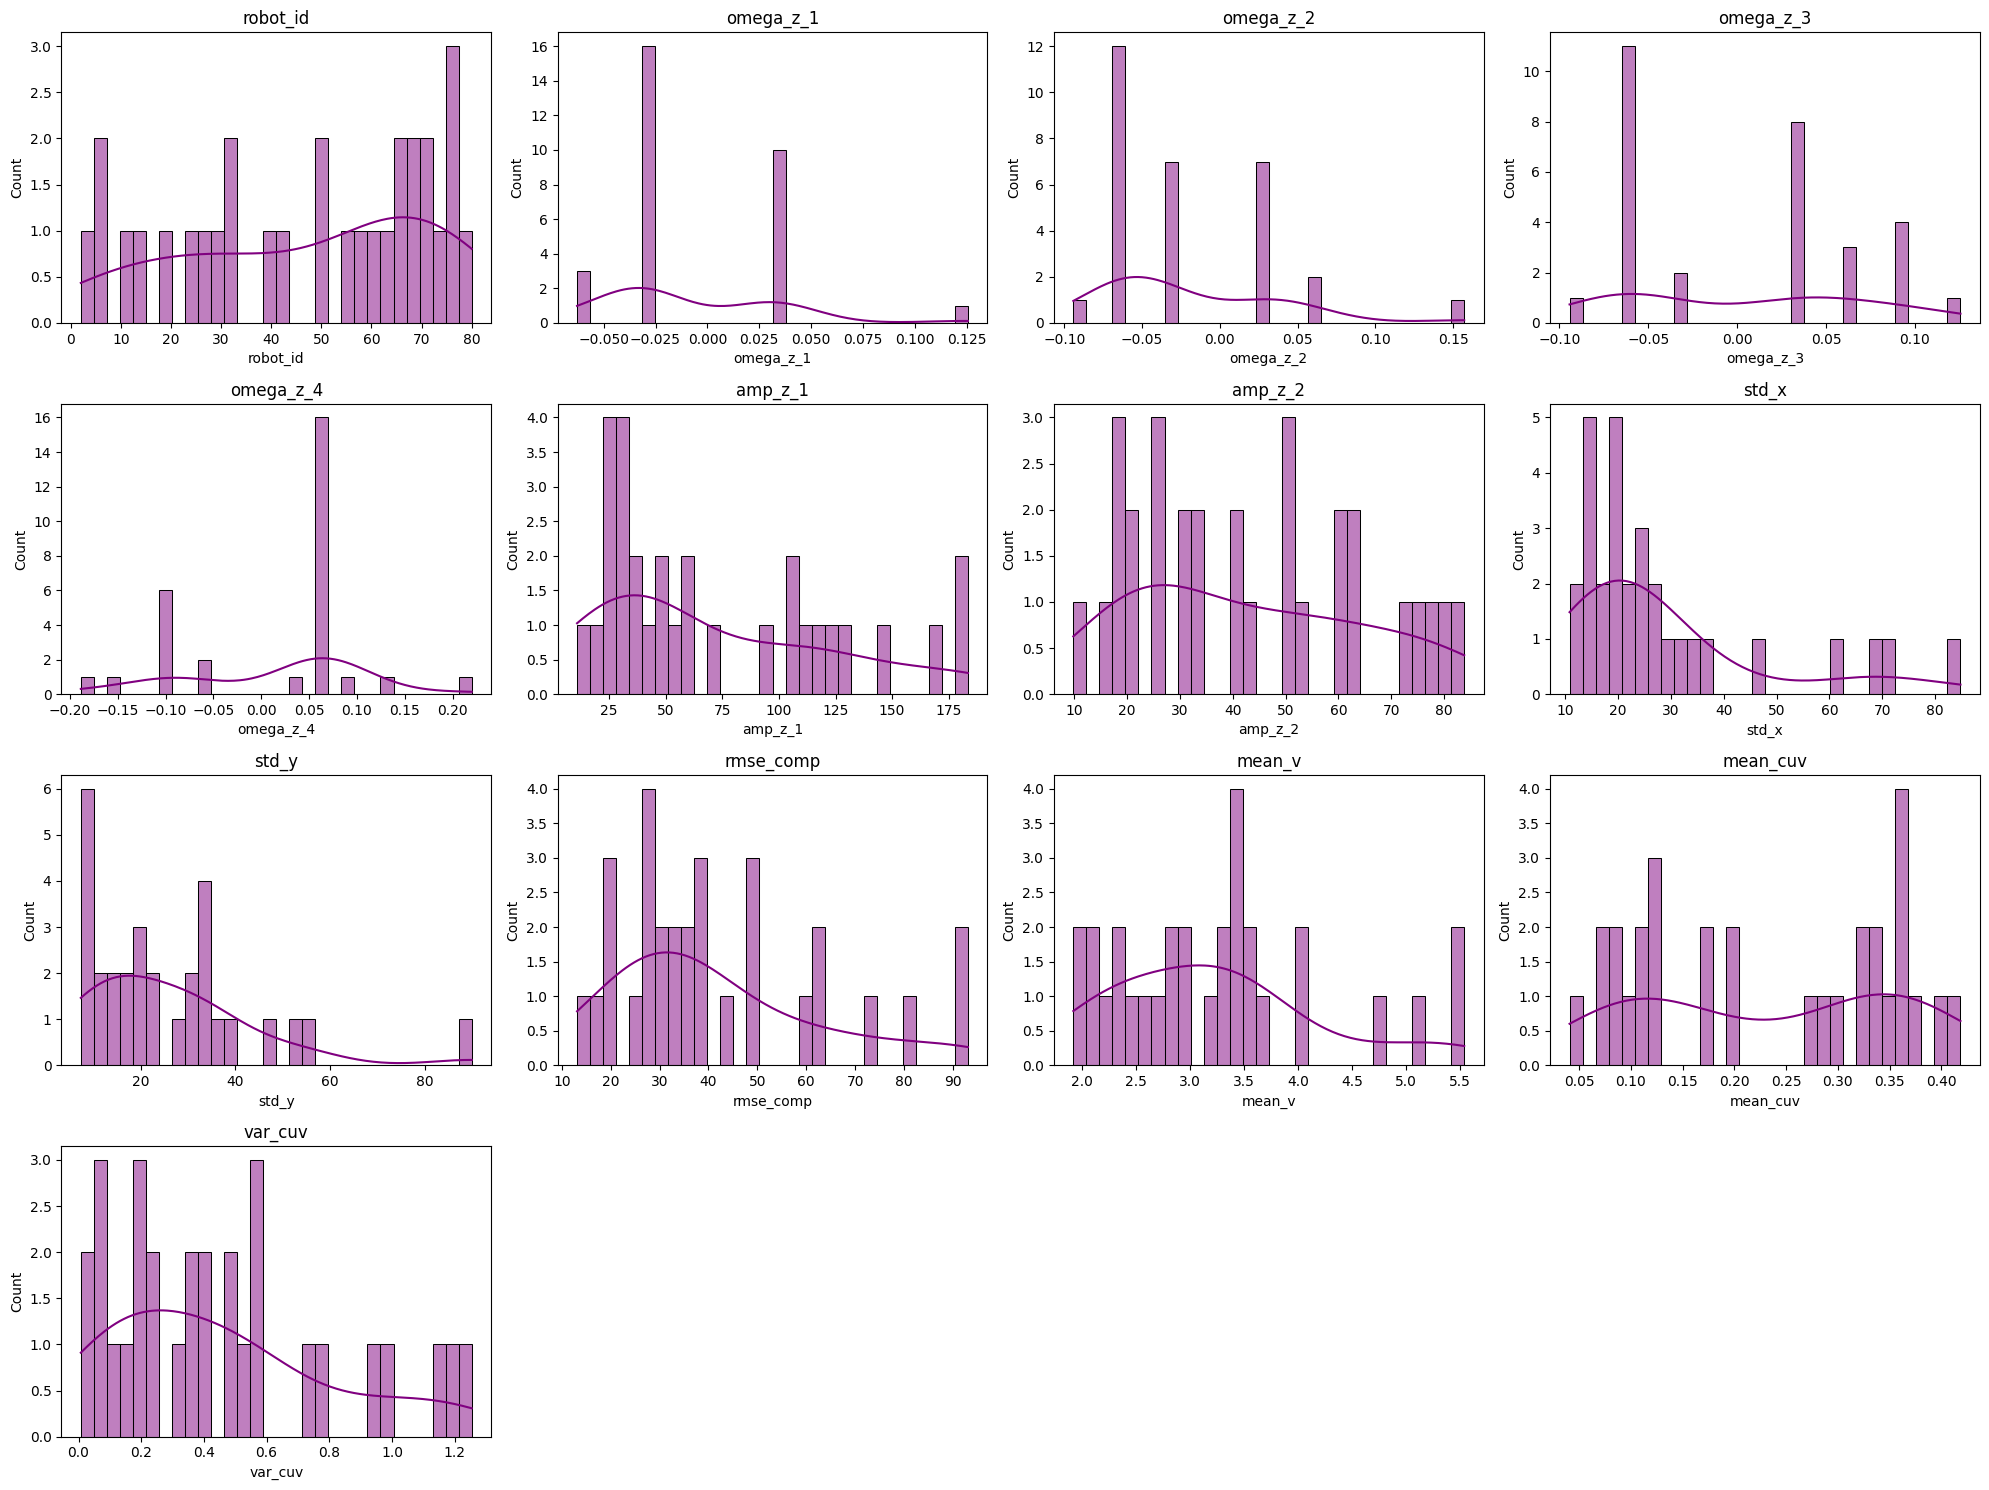

In [12]:
feature_creating = FeatureCollection(coord_data=coord_data, robots_form=robots_form, colors = colors, time_period=time_period, show_flag=False, save_flag = True)
feature_creating.feature_collection()
feature_creating.feature_analysis()

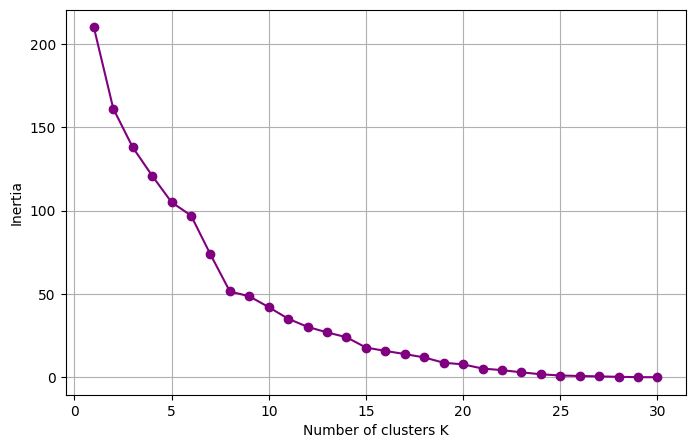

In [13]:
df = pd.read_csv(f'{robots_form}/robots_features.csv', index_col='robot_id')
#df = pd.read_csv(f'oval_robots_fft_parameters.csv')
df = df.drop(columns=['amp_z_2','rmse_comp','mean_v','mean_cuv','var_cuv'])
X = df
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
inertia = []
K_range = range(1, 31) 

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, 'o-', color='purple')
plt.xlabel('Number of clusters K')
plt.ylabel('Inertia') # (Sum of squared distances)
plt.grid(True)
save_dir = Path(robots_form) / 'figures'
plt.savefig(save_dir/"elbow_plot.pdf", bbox_inches='tight')
plt.show()


          omega_z_1  omega_z_2  omega_z_3  omega_z_4     amp_z_1      std_x  \
robot_id                                                                      
5         -0.062832   0.062832  -0.094248   0.094248   47.023941  31.498809   
39        -0.031416   0.031416  -0.062832   0.062832  114.719380  46.297173   
69        -0.031416   0.031416  -0.062832  -0.157080   24.783966  17.230830   
73        -0.031416   0.031416  -0.062832   0.062832  103.692036  35.216388   
13         0.031416  -0.031416  -0.062832   0.062832   35.800645  36.079136   
41         0.031416  -0.031416  -0.062832   0.062832   72.844103  13.916322   
57         0.031416  -0.062832  -0.031416   0.062832   22.871518  10.835966   
66         0.031416  -0.031416  -0.062832  -0.094248   52.505603  28.179458   
76         0.031416  -0.062832  -0.031416   0.062832   25.370632  25.198387   
77         0.031416  -0.031416  -0.062832   0.062832   61.551706  14.147733   
7         -0.031416   0.031416  -0.062832   0.062832

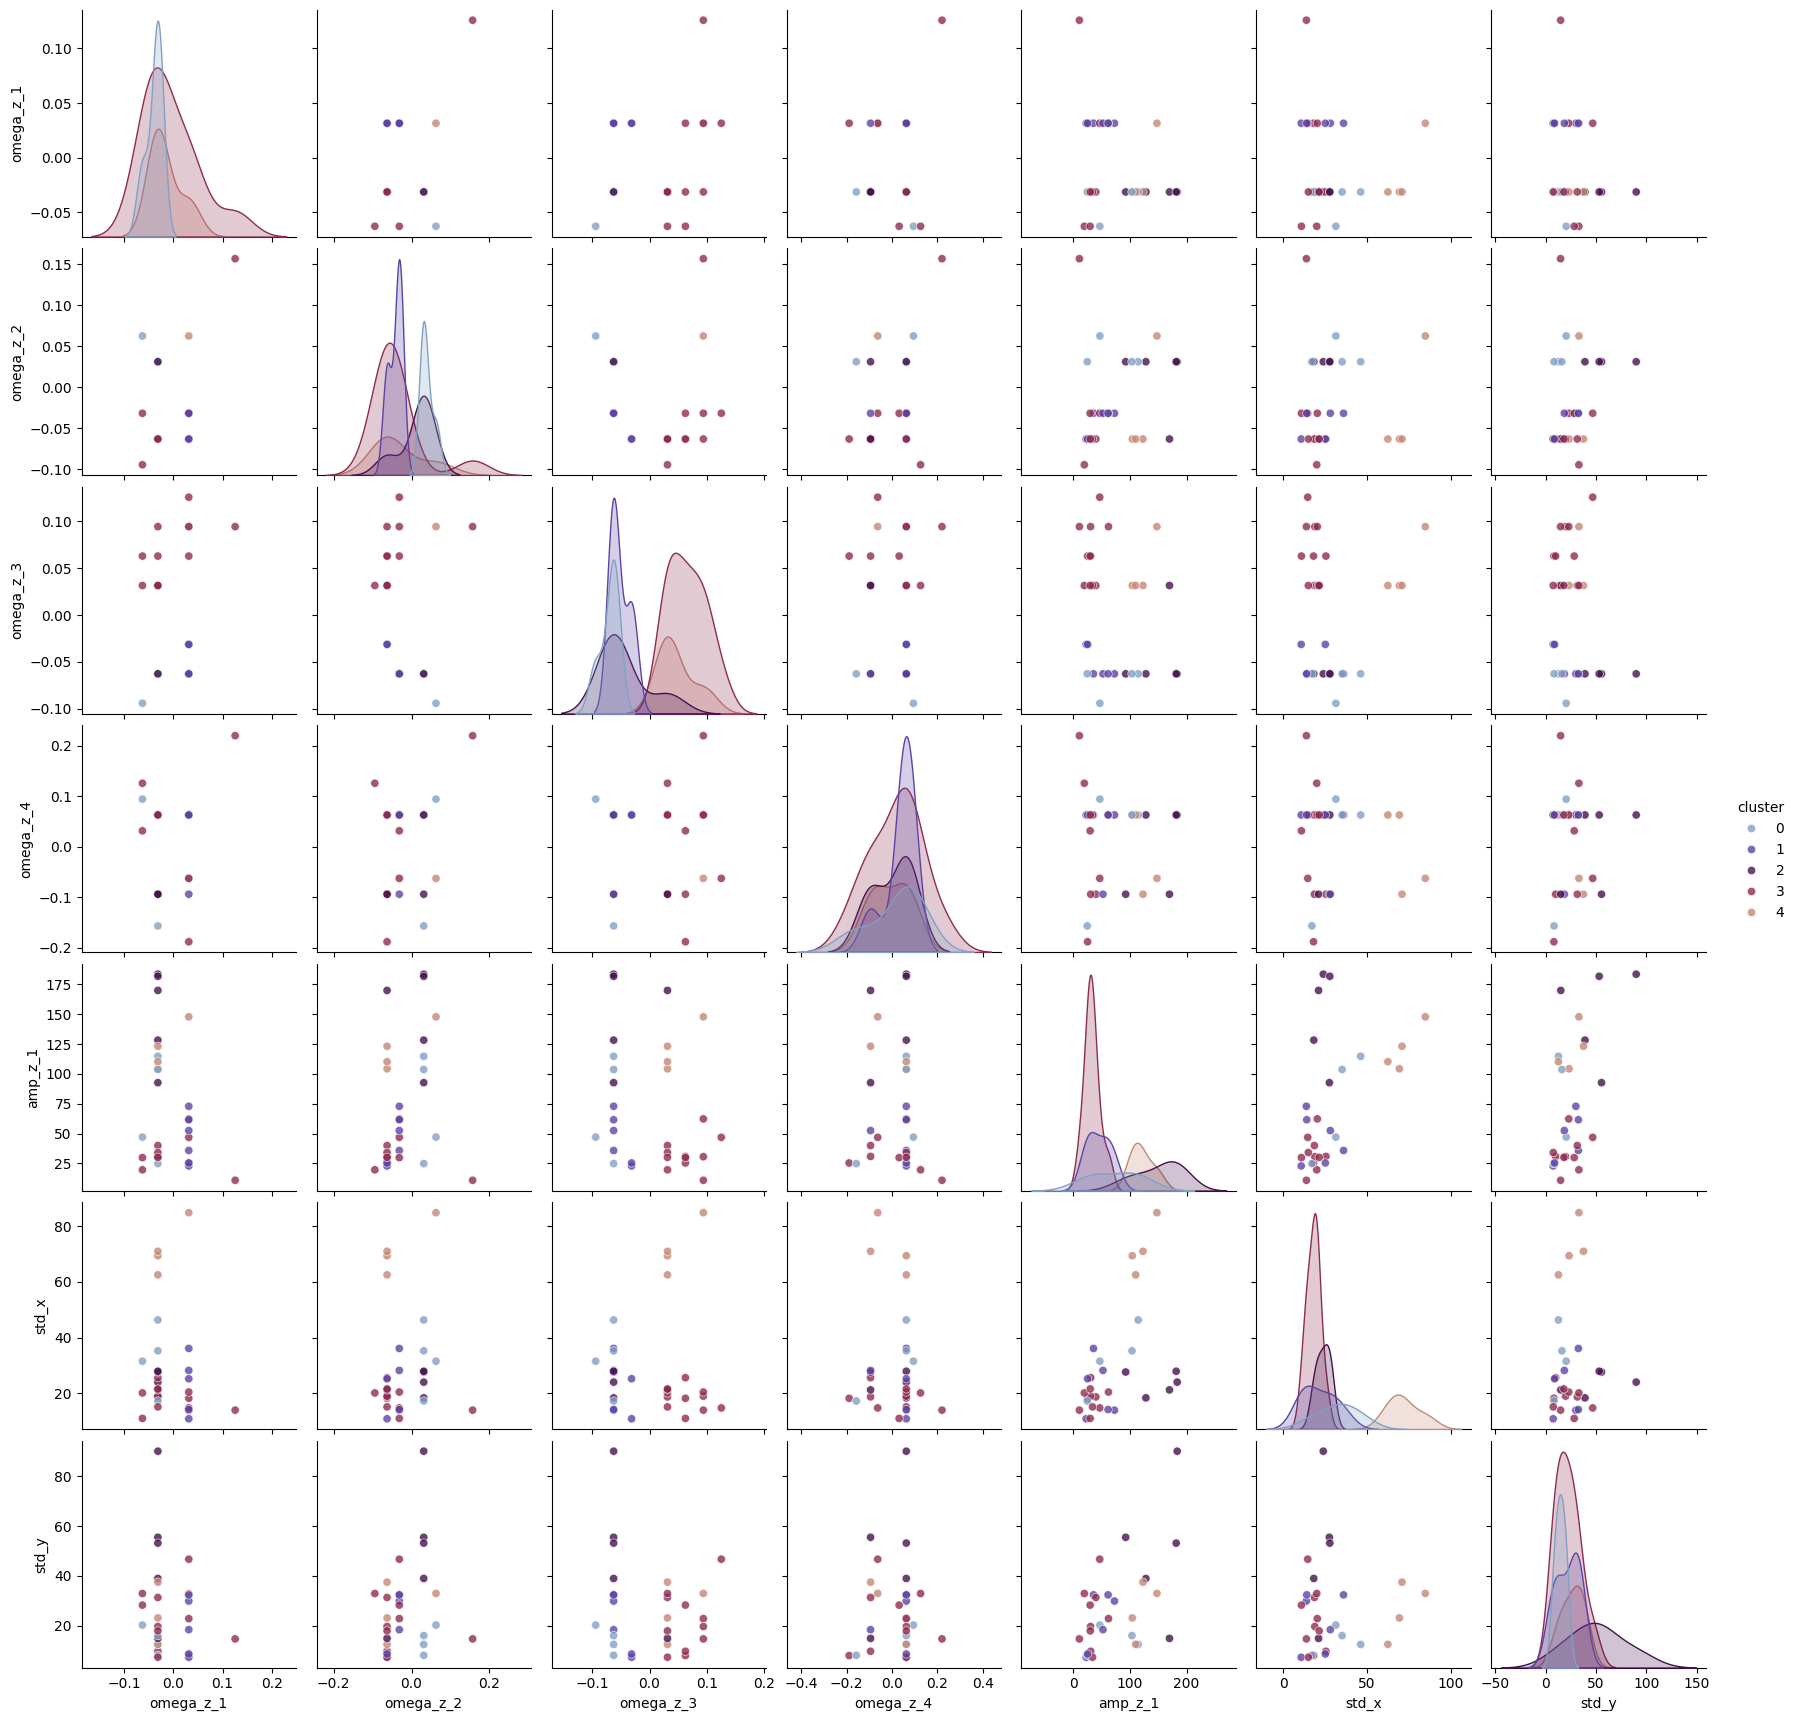

In [14]:
clusters = Clusterer(df, coord_data = coord_data, robots_form=robots_form ,n_clusters = 5, colors = colors, time_period = time_period, save_flag = True)
clusters.cluster_creating()
clusters.cluster_analysis()

# Initial experiments

In [ ]:
fig = make_subplots(rows=1, cols=1, shared_xaxes=True, vertical_spacing=0.05)
fig1 = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.05)
for i, robot_id in enumerate([79,74]):
    coords = np.array(coord_data[robot_id][:200])
    x, y = coords[:, 0], coords[:, 1]
    t = np.arange(len(x))
    if robot_id == 79:
        m = 60
        q = 1.2
        B = 7
        Ex0 = 2
        Ey0 =-8
        Ex = np.array([Ex0])
        Ey = np.array([Ey0])
        w = q * B/m
        k = -1/970/0.01
        W = k*w
        fi = math.atan(np.abs(Ey0)/np.abs(Ex0)) 

        x_p, y_p = coords[2:4, 0], coords[2:4, 1]
        vx = np.array([x_p[1] - x_p[0]])
        vy = np.array([y_p[1] - y_p[0]])
      
        dt = 0.005
        x_p, y_p = coords[0:1, 0], coords[0:1, 1]
        print(robot_id, x_p[0], y_p[0], vx, vy)
        x_p = np.append(x_p, x_p[0] + vx[-1]*dt)
        y_p = np.append(y_p, y_p[0] + vy[-1]*dt)
        for h in range(round(144/dt)): 
            vx = np.append(vx, vx[-1] + q/m * (Ex[-1] + B*vy[-1]) * dt)
            vy = np.append(vy, vy[-1] + q/m * (Ey[-1] - B*vx[-2]) * dt)
            x_p = np.append(x_p, x_p[-1] + vx[-1] * dt)
            y_p = np.append(y_p, y_p[-1] + vy[-1] * dt)
            Ex = np.append(Ex, np.sign(Ex0) * np.linalg.norm([Ex0,Ey0]) * np.cos(W*((h+1)*dt) + fi))
            Ey = np.append(Ey, np.sign(Ey0) * np.linalg.norm([Ex0,Ey0]) * np.sin(W*((h+1)*dt) + fi)) 
        
    else:
        m = 60
        q = 1.2
        B = -2.8
        Ex0 = -1.2
        Ey0 = -1.15
        Ex = np.array([Ex0])
        Ey =np.array([Ey0])
        w = q * B/m
        x_p, y_p = coords[0:2, 0], coords[0:2, 1]
        k = 1/5000/0.01
        W = k*w
        fi = math.atan(np.abs(Ey0)/np.abs(Ex0))

        vx = np.array([x_p[1] - x_p[0]])
        vy = np.array([y_p[1] - y_p[0]])
        print(robot_id, x_p[0], y_p[0], vx, vy)
        dt = 0.005
        x_p = np.append(x_p, x_p[0] + vx[-1]*dt)
        y_p = np.append(y_p, y_p[0] + vy[-1]*dt)

        for h in range(round(380/dt)):
            vx = np.append(vx, vx[-1] + q/m * (Ex[-1] + B*vy[-1])*dt)
            vy = np.append(vy, vy[-1] + q/m * (Ey[-1] - B*vx[-2])*dt)
            x_p = np.append(x_p, x_p[-1] + vx[-1]*dt)
            y_p = np.append(y_p, y_p[-1] + vy[-1]*dt)
            Ex = np.append(Ex, np.sign(Ex0) * np.linalg.norm([Ex0,Ey0]) * np.cos(W*((h+1)*dt) + fi))
            Ey = np.append(Ey, np.sign(Ey0) * np.linalg.norm([Ex0,Ey0]) * np.sin(W*((h+1)*dt) + fi)) 

    '''
    if robot_id == 79:
        RE = 73.91
        RB = 25.75
        f = -1.4*np.pi/3
        k = -1/970/0.01
        
        m = 60
        q = 1.2

        x_p, y_p = coords[2:4, 0], coords[2:4, 1]
        vx = np.array([x_p[1] - x_p[0]])
        vy = np.array([y_p[1] - y_p[0]])

        w = np.linalg.norm([vx[0],vy[0]])/RB
        B = m/q * w
        
        W = k*w
        E0 = RE * m/q * np.abs(W) * np.abs(np.sign(np.cos(f))*W + np.sign(np.sin(f))*w)
        Ex0 = E0 * np.cos(f)
        Ey0 = E0 * np.sin(f)

        Ex = np.array([Ex0])
        Ey = np.array([Ey0]) 
        fi = math.atan(np.abs(Ey0)/np.abs(Ex0))

        dt = 0.005
        x_p, y_p = coords[0:1, 0], coords[0:1, 1]
        print(robot_id, x_p[0], y_p[0], vx, vy)

        D = - q/m * np.sign(Ex0*Ey0) * np.linalg.norm([Ex0,Ey0])/(np.sign(Ex0)*W + np.sign(Ey0)*w)
        C = -D *np.sign(Ex0/Ey0)
        B = vy[0] - D*np.cos(fi)
        A = vx[0] - C*np.sin(fi)

        for h in range(round(144/dt)): #144/dt
            T = (h+1) * dt
            x_p = np.append(x_p, x_p[0] + B/w + C/W*np.cos(fi) + A/w*np.sin(w*T) - B/w*np.cos(w*T) - C/W*np.cos(W*T + fi))
            y_p = np.append(y_p, y_p[0] - A/w - D/W*np.sin(fi) + A/w*np.cos(w*T) + B/w*np.sin(w*T) + D/W*np.sin(W*T + fi))
    else:
        RE=519.60
        RB=96.16
        f = 0.76+np.pi
        k = 1/5000/0.01
        
        m = 60
        q = 1.2

        x_p, y_p = coords[0:2, 0], coords[0:2, 1]
        vx = np.array([x_p[1] - x_p[0]])
        vy = np.array([y_p[1] - y_p[0]])

        w = -np.linalg.norm([vx[0],vy[0]])/RB
        B = m/q * w
        
        W=k*w
        E0 = RE * m/q * np.abs(W) * np.abs(np.sign(np.cos(f))*W + np.sign(np.sin(f))*w)
        Ex0 = E0 * np.cos(f)
        Ey0 = E0 * np.sin(f)
        Ex = np.array([Ex0])
        Ey = np.array([Ey0]) 
        fi = math.atan(np.abs(Ey0)/np.abs(Ex0))
    
        dt = 0.005
        D = - q/m * np.sign(Ex0*Ey0) * np.linalg.norm([Ex0,Ey0])/(np.sign(Ex0)*W + np.sign(Ey0)*w)
        C = -D *np.sign(Ex0/Ey0)
        B = vy[0] - D*np.cos(fi)
        A = vx[0] - C*np.sin(fi)

        for h in range(round(380/dt)): #144/dt
            T = (h+1) * dt
            x_p = np.append(x_p, x_p[0] + B/w + C/W*np.cos(fi) + A/w*np.sin(w*T) - B/w*np.cos(w*T) - C/W*np.cos(W*T + fi))
            y_p = np.append(y_p, y_p[0] - A/w - D/W*np.sin(fi) + A/w*np.cos(w*T) + B/w*np.sin(w*T) + D/W*np.sin(W*T + fi))
    '''
    
    rmse = np.sqrt(np.mean((x - x_p[0:round(len(x_p)/len(t))*len(t):round(len(x_p)/len(t))])**2 + (y - y_p[0:round(len(x_p)/len(t))*len(t):round(len(x_p)/len(t))])**2))
    print("RMSE:", rmse)

    j=i*4+1
    fig.add_trace(go.Scatter(x=x[:], y=y[:], mode='lines', 
                             line=dict(color=colors[j], width=1), name=f'Trajectory, object {robot_id}'), 
                             row=1,col=1)
    fig.add_trace(go.Scatter(x=[x[0]], y=[y[0]], mode='markers', marker=dict(color=colors[j], symbol='circle', size=8),
                             line=dict(color=colors[j], width=1), name=f'Start, object {robot_id}'), 
                             row=1,col=1)
    fig.add_trace(go.Scatter(x=[x[-1]], y=[y[-1]], mode='markers', marker=dict(color=colors[j], symbol='x',size=8), 
                             line=dict(color=colors[j], width=1), name=f'End, object {robot_id}'), 
                             row=1,col=1)
    
    fig1.add_trace(go.Scatter(
        x=t, y=x, mode='lines',
        line=dict(color=colors[j], width=2),
        name=f'Coords., object {robot_id}'),
        row=1, col=1)
    fig1.add_trace(go.Scatter(
        x=t, y=y, mode='lines',
        line=dict(color=colors[j], width=2),
        name=f'Coords., object {robot_id}'), 
        row=2, col=1)

    j+=1
    fig.add_trace(go.Scatter(x=x_p[0:round(len(x_p)/len(t))*len(t):round(len(x_p)/len(t))], y=y_p[0:round(len(x_p)/len(t))*len(t):round(len(x_p)/len(t))], mode='lines',
                             line=dict(color=colors[j], width=1, dash='dash'), name=f'Trajectory, object {robot_id+100}'), 
                             row=1,col=1)
    fig.add_trace(go.Scatter(x=[x_p[0]], y=[y_p[0]], mode='markers', marker=dict(color=colors[j], symbol='circle', size=8),
                             line=dict(color=colors[j], width=1), name=f'Start, particle {robot_id+100}'), 
                             row=1,col=1)
    fig.add_trace(go.Scatter(x=[x_p[-1]], y=[y_p[-1]], mode='markers', marker=dict(color=colors[j], symbol='x',size=8), 
                             line=dict(color=colors[j], width=1), name=f'End, particle {robot_id+100}'), 
                             row=1,col=1)
    
    fig1.add_trace(go.Scatter(
        x=t, y=x_p[0:round(len(x_p)/len(t))*len(t):round(len(x_p)/len(t))], mode='lines',
        line=dict(color=colors[j], width=2, dash='dash'), name=f'Coords., particle {robot_id+100}'),
        row=1, col=1)
    fig1.add_trace(go.Scatter(
        x=t, y=y_p[0:round(len(x_p)/len(t))*len(t):round(len(x_p)/len(t))],mode='lines',
        line=dict(color=colors[j], width=2, dash='dash'), name=f'Coords., particle {robot_id+100}'), 
        row=2, col=1)

    fig.update_layout(
        height=600,
        width=900,
        plot_bgcolor='white',
        font=dict(family="Inter", size=13),
        margin=dict(l=40, r=10, t=20, b=60),
        legend=dict(
            x=0.8,     
            y=1, 
            xanchor='left',
            yanchor='top',
            bgcolor='rgba(0,0,0,0)'
        )
    )
    fig.update_xaxes(
        title_text="X Coordinate",
        tickmode='array',
        showgrid=True,gridcolor='lightgrey', mirror=True, showline=True, linewidth=1, linecolor='black',
        row=1, col=1
    )
    fig.update_yaxes(
        title_text="Y Coordinate", 
        row=1, col=1,
        showline=True, linewidth=1, linecolor='black',
        mirror=True, gridcolor='lightgrey',
        scaleanchor="x", scaleratio=0.5
        )

    fig1.update_layout(
        height=700,
        width=1000,
        plot_bgcolor='white',
        font=dict(family="Inter", size=13),
        margin=dict(l=40, r=10, t=20, b=60),
        legend=dict(
            x=0.83,      
            y=1,   
            xanchor='left',
            yanchor='top',
            bgcolor='rgba(0,0,0,0)'
        ),
        legend_tracegroupgap=240,
    )
    fig1.update_xaxes(
        tickmode='array',
        showgrid=True, mirror=True,showline=True, linewidth=1, linecolor='black',#gridcolor='lightgrey',
        row=1, col=1
    )
    fig1.update_xaxes(
        title_text="Time",
        tickmode='array',
        showgrid=True, mirror=True, showline=True, linewidth=1, linecolor='black',#gridcolor='lightgrey',
        row=2, col=1
    )
    fig1.update_yaxes(
        title_text="X Coordinate",
        row=1, col=1,
        showline=True, linewidth=1, linecolor='black',
        mirror=True, #gridcolor='lightgrey'
    )
    fig1.update_yaxes(
        title_text="Y Coordinate", 
        row=2, col=1,
        showline=True, linewidth=1, linecolor='black',
        mirror=True)
    
    for x_val in [32,36, 90,95, 146,152,192,198]:  
        fig1.add_vline(
            x=x_val,
            line=dict(color='gray', width=1.5, dash='dot'),
            row='all', col=1
        )
fig.show()
fig1.show()


79 2421 1574 [3] [-2]
RMSE: 29.101312067119725
74 2439 1254 [5] [-2]
RMSE: 52.00910052946713
